In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("requests_responses.csv", low_memory=True)

df.head()



,id,timestamp,testcase,path,type,data,url,body,inputid,runid,id.1,timestamp.1,status,error,data.1,reqid
0,1,2026-03-24T12:18:04.038Z,NaN,/users,POST,curl http://localhost/v1/users? \\n --reque...,http://localhost/v1/users?,NaN,1,1,1,2026-03-24T12:18:04.065Z,400,NaN,"{""message"":""Missing or unknown project ID"",""co...",1
1,2,2026-03-24T12:18:05.754Z,NaN,/account/prefs,GET,curl http://localhost/v1/account/prefs? \\n ...,http://localhost/v1/account/prefs?,NaN,2,1,2,2026-03-24T12:18:05.768Z,400,NaN,"{""message"":""Missing or unknown project ID"",""co...",2
2,3,2026-03-24T12:18:05.781Z,NaN,/account/recovery,POST,curl http://localhost/v1/account/recovery? \\n...,http://localhost/v1/account/recovery?,NaN,3,1,3,2026-03-24T12:18:05.801Z,400,NaN,"{""message"":""Missing or unknown project ID"",""co...",3
3,4,2026-03-24T12:18:05.814Z,NaN,/account/recovery,POST,curl http://localhost/v1/account/recovery? \\n...,http://localhost/v1/account/recovery?,NaN,4,1,4,2026-03-24T12:18:05.824Z,400,NaN,"{""message"":""Missing or unknown project ID"",""co...",4
4,5,2026-03-24T12:18:05.840Z,NaN,/health/queue/certificates,GET,curl http://localhost/v1/health/queue/certific...,http://localhost/v1/health/queue/certificates?,NaN,5,1,5,2026-03-24T12:18:05.852Z,400,NaN,"{""message"":""Missing or unknown project ID"",""co...",5


In [2]:
df.describe()


,id,inputid,runid,id.1,status,error,reqid
count,879058.000000,879058.000000,879058.000000,879058.000000,879058.000000,0.0,879058.000000
mean,439529.500000,86566.761519,11.457196,439529.500000,347.999502,NaN,439529.500000
std,253762.330804,50544.877394,1.366174,253762.330804,91.776512,NaN,253762.330804
min,1.000000,1.000000,1.000000,1.000000,200.000000,NaN,1.000000
25%,219765.250000,43864.250000,11.000000,219765.250000,200.000000,NaN,219765.250000
50%,439529.500000,86226.000000,12.000000,439529.500000,401.000000,NaN,439529.500000
75%,659293.750000,126962.000000,12.000000,659293.750000,401.000000,NaN,659293.750000
max,879058.000000,184260.000000,13.000000,879058.000000,500.000000,NaN,879058.000000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 879058 entries, 0 to 879057
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           879058 non-null  int64  
 1   timestamp    879058 non-null  str    
 2   testcase     875727 non-null  str    
 3   path         879058 non-null  str    
 4   type         879058 non-null  str    
 5   data         879058 non-null  str    
 6   url          879058 non-null  str    
 7   body         65456 non-null   str    
 8   inputid      879058 non-null  int64  
 9   runid        879058 non-null  int64  
 10  id.1         879058 non-null  int64  
 11  timestamp.1  879058 non-null  str    
 12  status       879058 non-null  int64  
 13  error        0 non-null       float64
 14  data.1       879051 non-null  str    
 15  reqid        879058 non-null  int64  
dtypes: float64(1), int64(6), str(9)
memory usage: 107.3 MB


In [4]:
df.dtypes

id               int64
timestamp          str
testcase           str
path               str
type               str
data               str
url                str
body               str
inputid          int64
runid            int64
id.1             int64
timestamp.1        str
status           int64
error          float64
data.1             str
reqid            int64
dtype: object

In [5]:
df.shape

(879058, 16)

In [6]:
df.isnull().sum()

id                  0
timestamp           0
testcase         3331
path                0
type                0
data                0
url                 0
body           813602
inputid             0
runid               0
id.1                0
timestamp.1         0
status              0
error          879058
data.1              7
reqid               0
dtype: int64

In [7]:
df.nunique()

id             879058
timestamp      879058
testcase           95
path               86
type                5
data           354225
url            329006
body            61695
inputid        184260
runid              13
id.1           879058
timestamp.1    879058
status              8
error               0
data.1            725
reqid          879058
dtype: int64

In [8]:
df["runid"].value_counts()

runid
11    240590
12    227823
13    215983
10    182906
3       2765
4       2472
2       2250
9       1839
6        800
8        625
5        486
7        392
1        127
Name: count, dtype: int64

In [9]:
df["status"].value_counts()

status
401    463447
200    242167
429     80139
400     79727
404     12827
201       636
500       109
204         6
Name: count, dtype: int64

In [10]:
df["reqid"].value_counts()

reqid
1         1
2         1
3         1
4         1
5         1
         ..
879054    1
879055    1
879056    1
879057    1
879058    1
Name: count, Length: 879058, dtype: int64

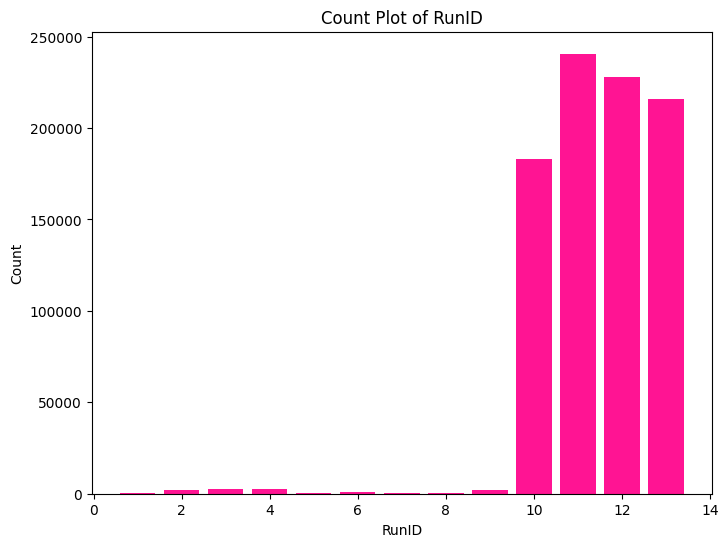

In [11]:
quality_counts = df['runid'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(quality_counts.index, quality_counts, color='deeppink')
plt.title('Count Plot of RunID')
plt.xlabel('RunID')
plt.ylabel('Count')
plt.show()

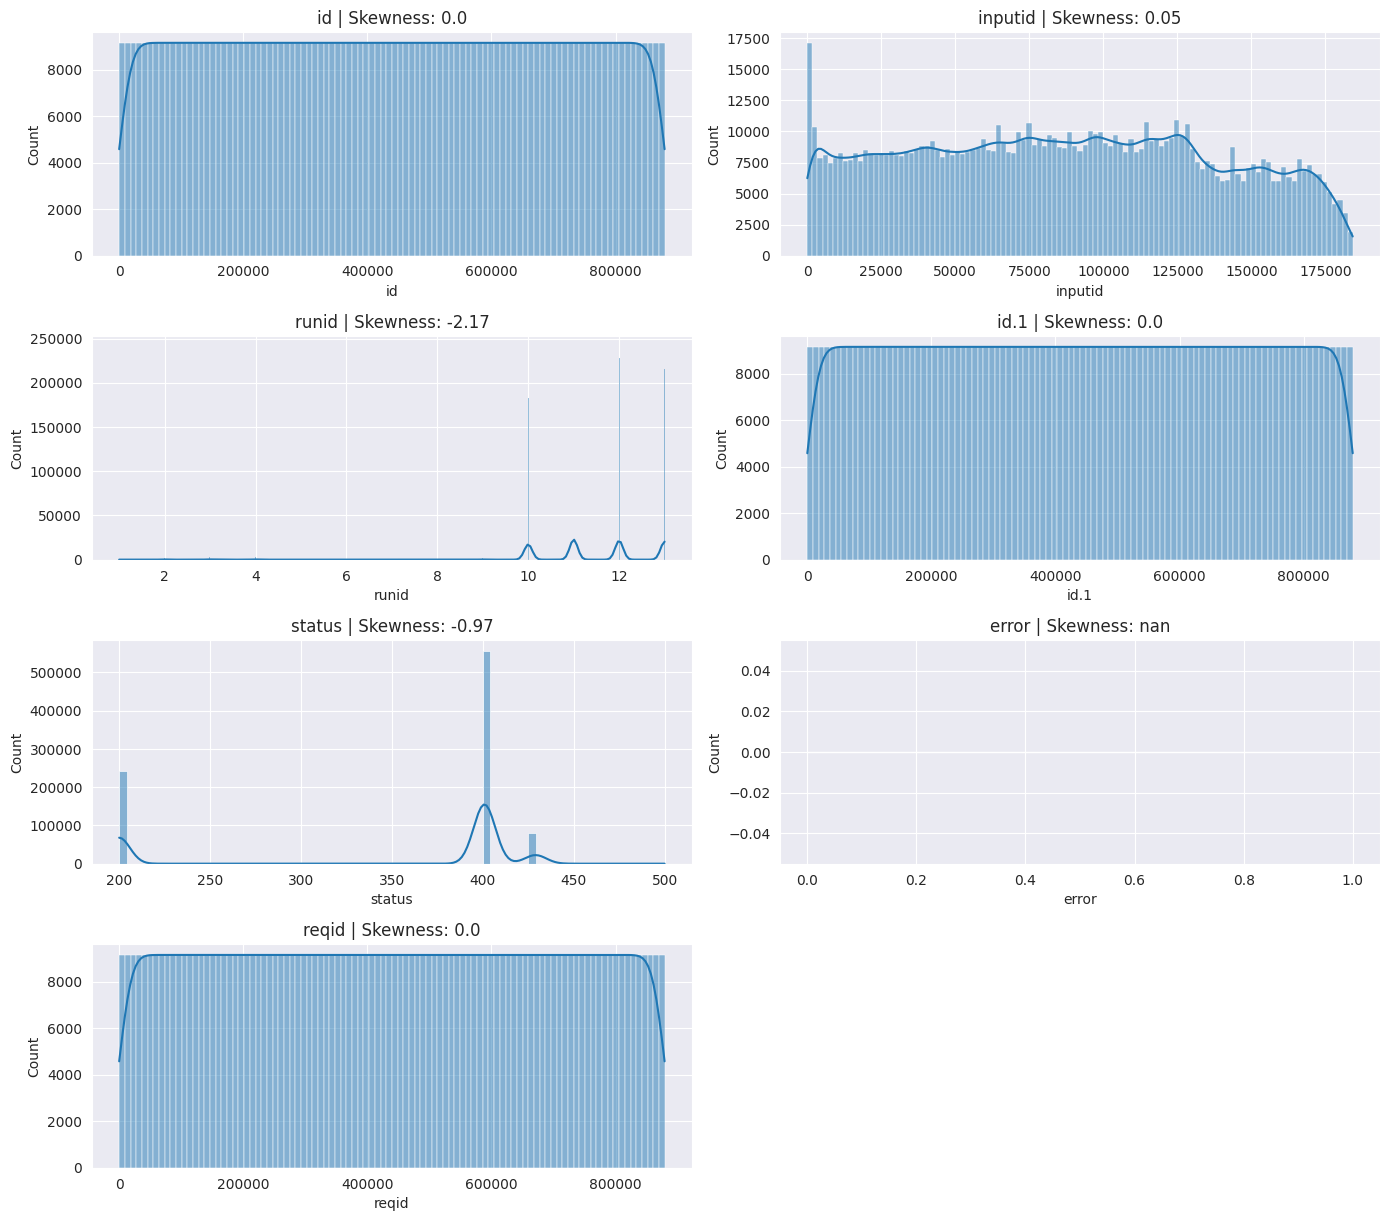

In [12]:
sns.set_style("darkgrid")

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

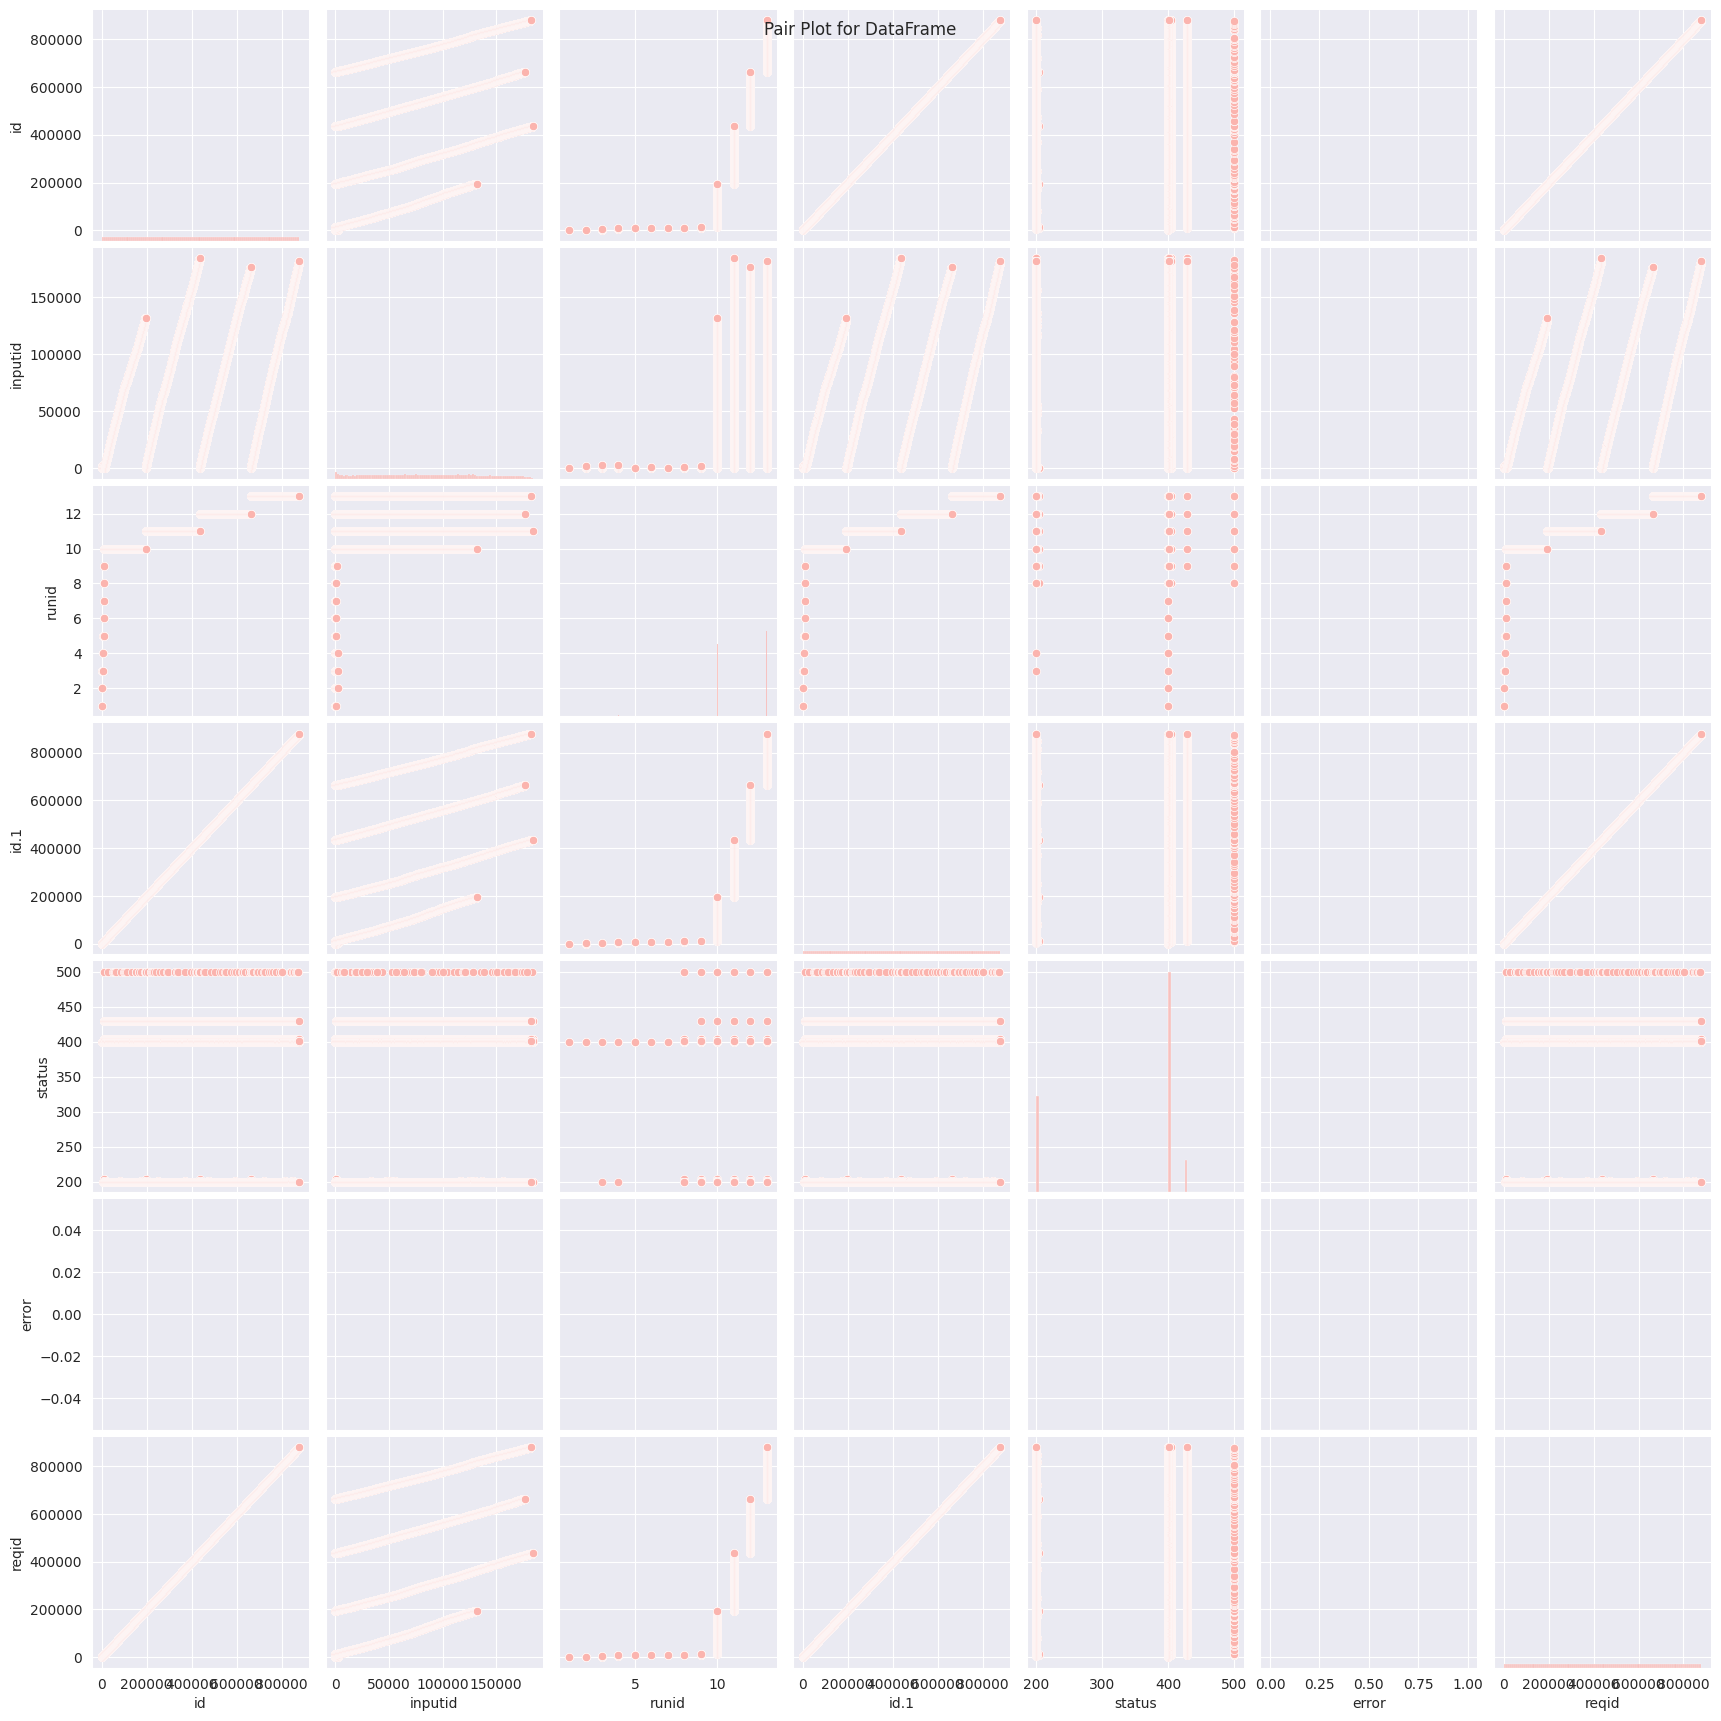

In [13]:
sns.set_palette("Pastel1")

plt.figure(figsize=(10, 6))

sns.pairplot(df)

plt.suptitle('Pair Plot for DataFrame')
plt.show()

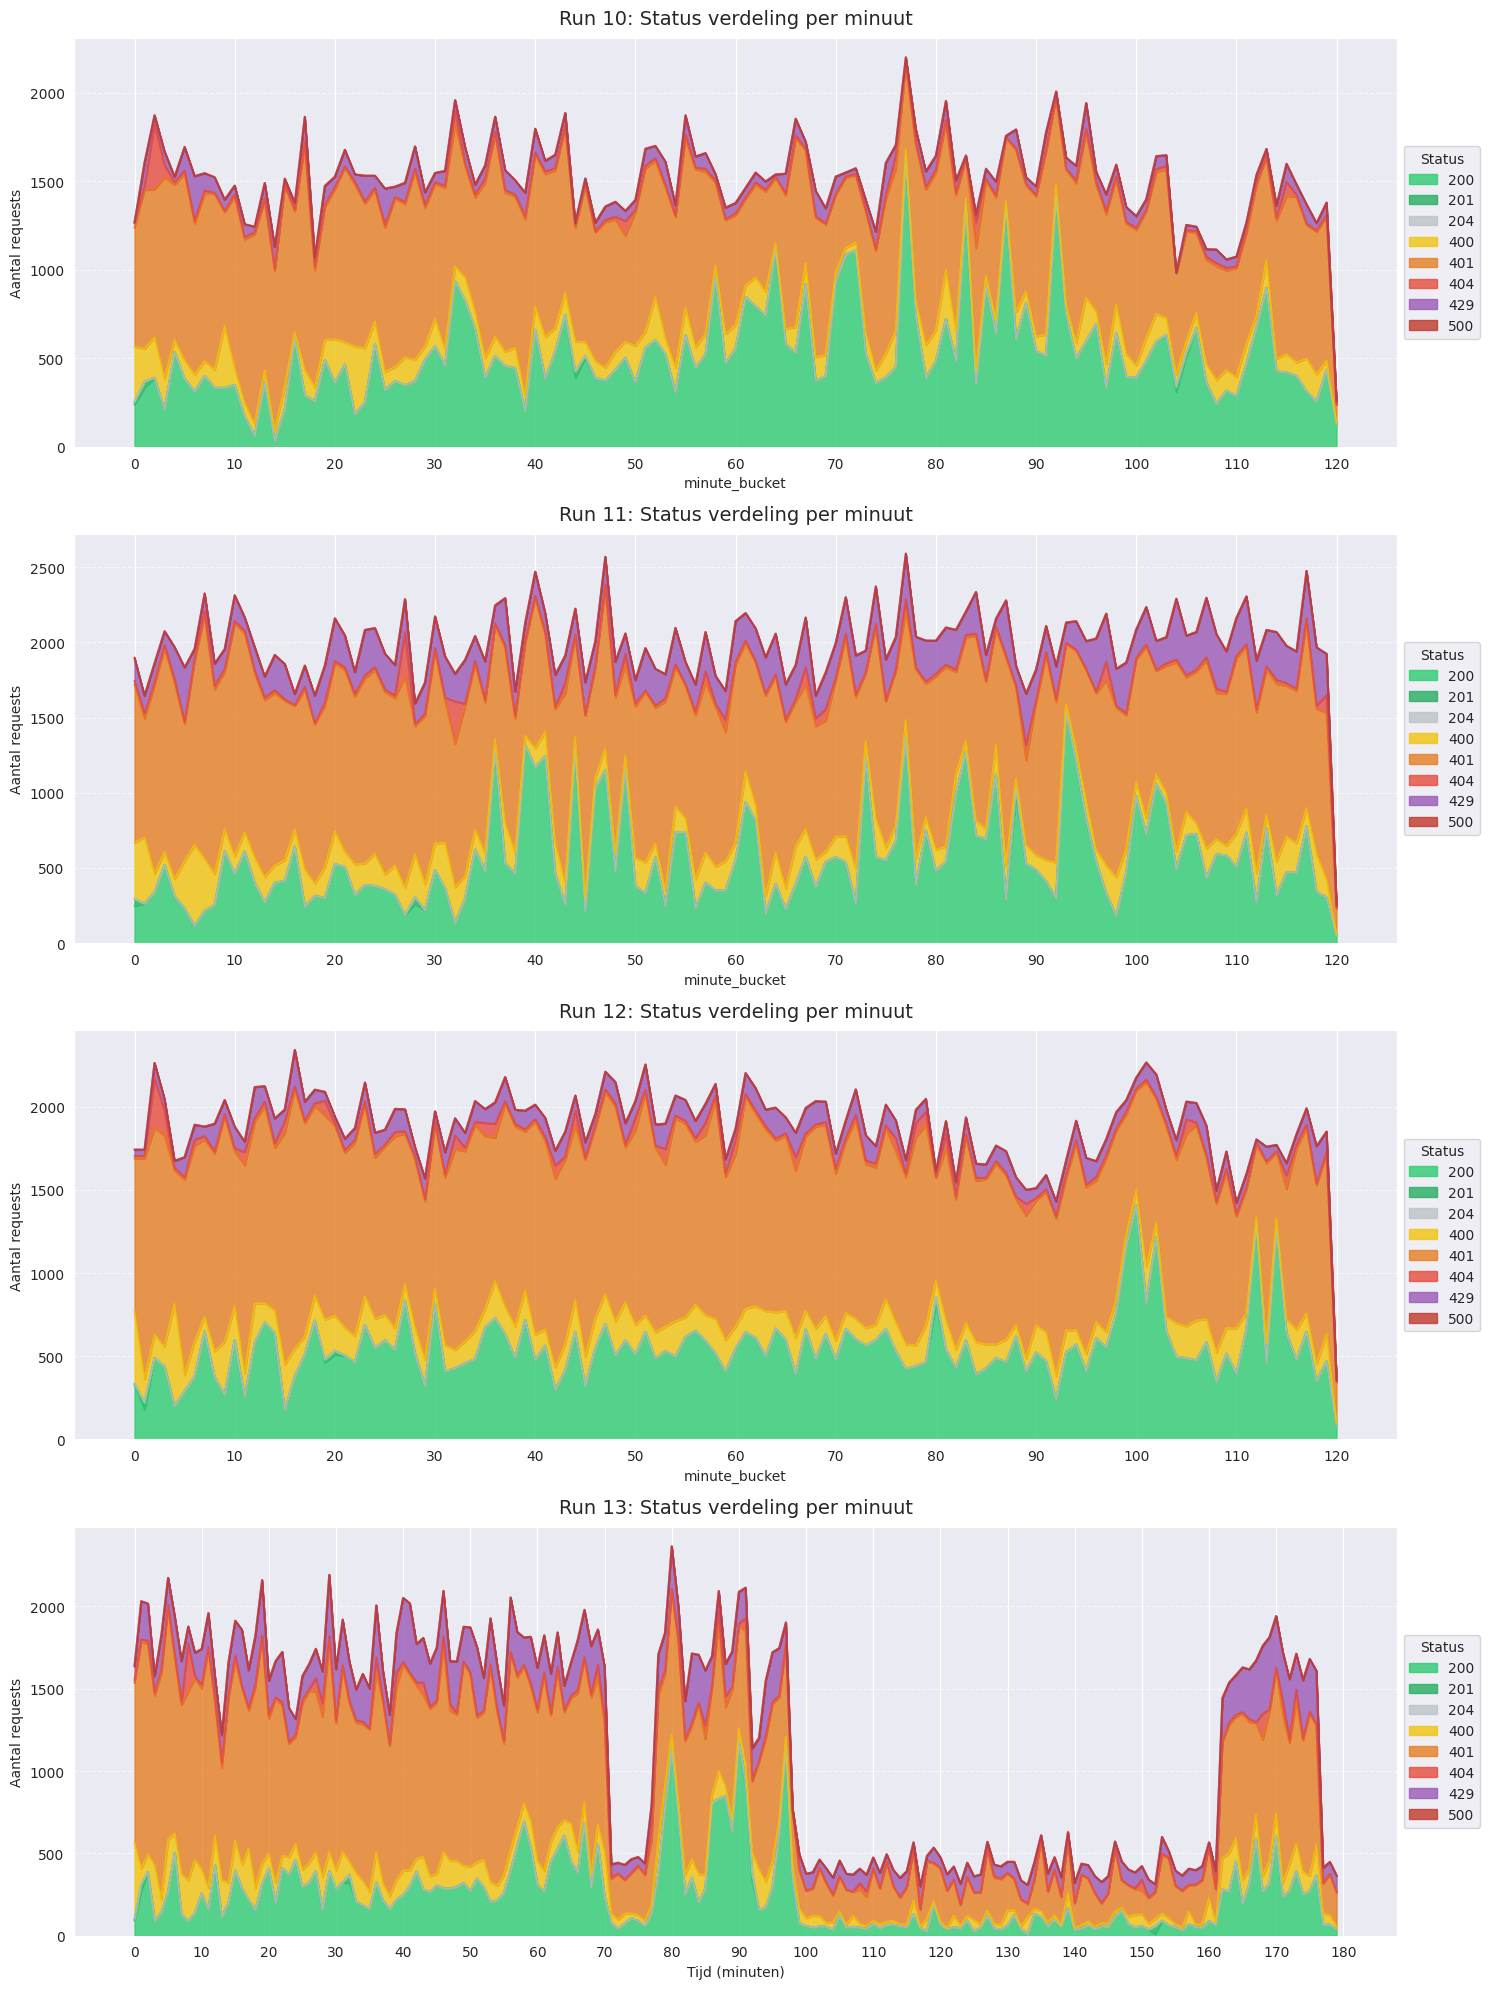

In [19]:

df['minute_bucket'] = (df['seconds'] // 60).astype(int)
summary = df.groupby(['runid', 'minute_bucket', 'status']).size().unstack(fill_value=0)

import matplotlib.ticker as ticker


runids = [rid for rid in df['runid'].unique() if rid > 9]

if len(runids) > 0:
    fig, axes = plt.subplots(len(runids), 1, figsize=(15, 5 * len(runids)), sharex=False)
    if len(runids) == 1: axes = [axes]

    color_map = {
        200: "#2ecc71", 201: "#27ae60", 400: "#f1c40f", 
        401: "#e67e22", 404: "#e74c3c", 429: "#9b59b6", 500: "#c0392b"
    }

    for i, rid in enumerate(runids):
        run_data = summary.loc[rid]
        
        #
        run_data.plot(kind='area', stacked=True, ax=axes[i], 
                      color=[color_map.get(col, "#bdc3c7") for col in run_data.columns],
                      alpha=0.8)
        
        axes[i].set_title(f"Run {rid}: Status verdeling per minuut", fontsize=14, pad=10)
        axes[i].set_ylabel("Aantal requests")
        axes[i].grid(True, axis='y', linestyle='--', alpha=0.7)
        
        
        axes[i].xaxis.set_major_locator(ticker.MultipleLocator(10)) 
        
        
        axes[i].legend(title="Status", loc='center left', bbox_to_anchor=(1, 0.5))

    plt.xlabel("Tijd (minuten)")
    plt.tight_layout()
    plt.show()

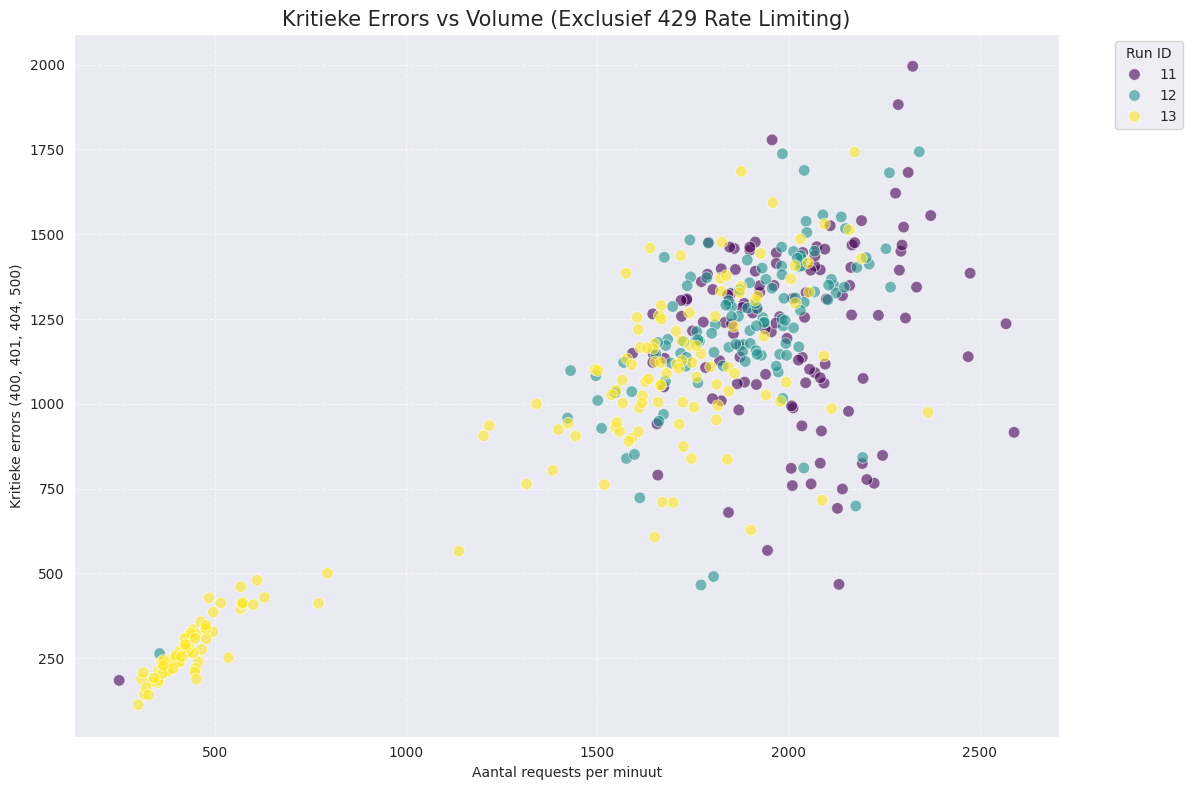

In [20]:

filtered_error_codes = [400, 401, 404, 500]

# 2. Bereken de data opnieuw
scatter_data = summary.copy()
scatter_data['total_requests'] = scatter_data.sum(axis=1)

# We pakken alleen de kolommen die in onze nieuwe lijst staan
available_errors = [col for col in filtered_error_codes if col in scatter_data.columns]
scatter_data['critical_errors'] = scatter_data[available_errors].sum(axis=1)

# Reset index en filter op Run ID > 10
scatter_plot_df = scatter_data.reset_index()
scatter_plot_df = scatter_plot_df[scatter_plot_df['runid'] > 10]

# 3. Plotten
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=scatter_plot_df, 
    x='total_requests', 
    y='critical_errors', 
    hue='runid', 
    palette='viridis', # Andere kleurset voor de variatie
    alpha=0.6,
    s=70
)

plt.title('Kritieke Errors vs Volume (Exclusief 429 Rate Limiting)', fontsize=15)
plt.xlabel('Aantal requests per minuut')
plt.ylabel('Kritieke errors (400, 401, 404, 500)')
plt.legend(title="Run ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Inzichten

1. Run 11 is de "Optimale Stress-tester"
deze run veruit de meeste requests per minuut verwerkt (tot boven de 2500).

Inzicht: De errors in Run 11 schalen lineair mee met het volume, maar de run "stikt" niet. Dat de punten helemaal rechts in de grafiek staan zonder verticaal te exploderen, betekent dat de server de load technisch aan kan, mits de client de 429's (die we nu negeren) respecteert.

2. De "Danger Zone" rond de 1500-2000 requests
Er lijkt een kantelpunt te zitten rond de 1750 requests per minuut.

Inzicht: Onder de 1500 requests zie je een redelijk voorspelbaar patroon. Zodra je boven de 1750 komt, zie je de spreiding op de Y-as (Kritieke errors) enorm toenemen. Dit suggereert dat je systeem hier zijn comfortzone verlaat en onvoorspelbaar begint te reageren.

3. Run 13: De "Low-Volume instability"
Kijk naar de gele punten (Run 13) linksonder (rond de 500 requests).

Inzicht: Terwijl andere runs bij 500 requests vrijwel nul errors hebben, vertoont Run 13 daar al een cluster aan fouten. Dit is interessant: het suggereert dat Run 13 problemen had die niet gerelateerd waren aan drukte, maar mogelijk aan een configuratiefout, koude opstart (cold start) of een falende afhankelijkheid aan het begin van de run.

4. De "Cloud" vorming
De meeste punten clusteren tussen de 750 en 1500 kritieke errors bij een load van 1500+ requests.

Inzicht: Een error-rate van bijna 50% (bijv. 1000 errors op 2000 requests) is extreem hoog voor "kritieke" fouten. Omdat dit over alle runs heen gebeurt, lijkt het erop dat er een harde bottleneck zit in een onderliggend systeem (zoals een database-timeout of een falende microservice) die consequent optreedt zodra de belasting serieus wordt.

# Vervolgstappen
1. Verwijderen van id.1, path, testcase, data, error, timestamp.1 en reqid vanwege lege waarden + dubbele kolommen
2. Verwijderen van alle runs onder 10 omdat ze te weinig info bevatten voor iets relevant
3. Verwijderen van error 429, irrelevant aangezien het probleem bij de programma lag dat ingesteld werd
4. One hot encoding voor: body, type , data.1
5. Random 150000 kolommen nemen en stratified sampling toepassen
